## Data Importing

In [47]:
import pandas as pd

# Load dataset
file_path = "https://gitlab.crio.do/me_notebook/me_jupyter_airbnbanalysis/-/raw/master/Airbnb_data.csv"
df = pd.read_csv(file_path)


In [48]:
df.shape

(48895, 16)

## Data Exploration

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [50]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## Handling Missing Values

In [51]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [52]:

# Fill missing values where necessary
df["reviews_per_month"].fillna(0, inplace=True)  # Replace NaNs with 0 for review counts
df.drop(columns=["last_review"], inplace=True)  # Drop last_review since it is not needed
# Replace only missing values in 'name' and 'host_name' with 'unknown'
df["name"].fillna("unknown", inplace=True)
df["host_name"].fillna("unknown", inplace=True)


/tmp/ipykernel_171/771477503.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["reviews_per_month"].fillna(0, inplace=True)  # Replace NaNs with 0 for review counts
/tmp/ipykernel_171/771477503.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col

In [53]:
# Re-check missing values
df.isnull().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

## Handling Outliers

In [54]:


# Selecting only numeric columns
import matplotlib.pyplot as plt
numeric_columns = df.select_dtypes(include=['number']).columns


# plt.figure(figsize=(8, 5))
# plt.boxplot(df[price], vert=False, patch_artist=True)
# plt.title(f"Boxplot of price")
# plt.xlabel("Price")
# plt.grid(True)
# plt.show()

In [55]:

# Ensure data types are correct
df["price"] = pd.to_numeric(df["price"], errors='coerce')
df["availability_365"] = pd.to_numeric(df["availability_365"], errors='coerce')


In [56]:


# Remove outliers (if necessary)
df = df[df["price"] > 0]  # Remove listings with zero or negative price
df = df[df["minimum_nights"] < 365]  # Remove extreme long-term stays

In [57]:



import numpy as np

Q1 = df["number_of_reviews"].quantile(0.25)  # First quartile
Q3 = df["number_of_reviews"].quantile(0.75)  # Third quartile
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


# Cap outliers at threshold values
df["number_of_reviews"] = np.where(df["number_of_reviews"] < lower_bound, lower_bound, df["number_of_reviews"])
df["number_of_reviews"] = np.where(df["number_of_reviews"] > upper_bound, upper_bound, df["number_of_reviews"])

In [58]:
import numpy as np

Q1 = df["price"].quantile(0.25)  # First quartile
Q3 = df["price"].quantile(0.75)  # Third quartile
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


# Cap outliers at threshold values
df["price"] = np.where(df["price"] < lower_bound, lower_bound, df["price"])
df["price"] = np.where(df["price"] > upper_bound, upper_bound, df["price"])

In [59]:
# Follow the same for other columns

## Understanding Customer Preferences

<Figure size 1200x600 with 0 Axes>

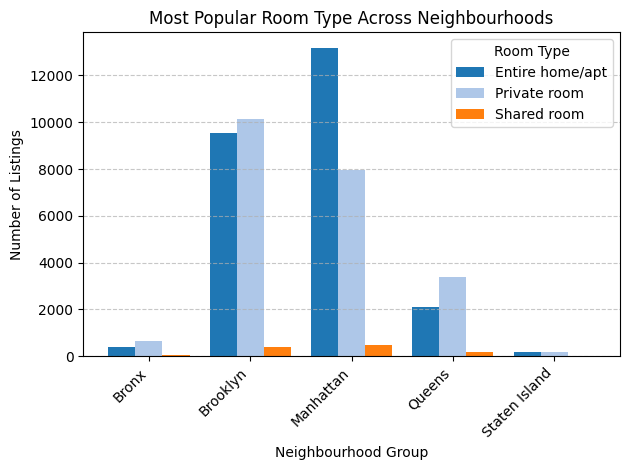

In [60]:
import numpy as np
import matplotlib.pyplot as plt

# Understanding Customer Preferences


# TODO:
# 1. Group data by 'neighbourhood_group' and 'room_type', count listings, and reshape with unstack().
# 2. Fill any missing values with 0 for better visualization.
# 3. Create a bar plot to visualize room type popularity across neighborhoods:
#    - Set appropriate figure size.
#    - Use a colormap for visual appeal.
#    - Rotate x-axis labels for readability.
#    - Add title, axis labels, and legend.
#    - Display the plot.
import numpy as np
import matplotlib.pyplot as plt

# 1. Group data by neighbourhood_group and room_type, count listings, and reshape with unstack()
grouped = df.groupby(['neighbourhood_group', 'room_type']).size().unstack(fill_value=0)

# 2. (Already handled by fill_value=0 above) – Fill any missing values with 0 for better visualization
#    grouped = grouped.fillna(0)  # optional if using unstack(fill_value=0)

# 3. Create a bar plot to visualize room type popularity across neighbourhoods
plt.figure(figsize=(12, 6))
# Choose a colormap
colors = plt.cm.tab20.colors

grouped.plot(kind='bar', color=colors, width=0.8)

plt.title('Most Popular Room Type Across Neighbourhoods')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Room Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


/tmp/ipykernel_171/3185748135.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_pr = df.groupby(['neighbourhood_group', 'price_range']).size().unstack(fill_value=0)


<Figure size 1200x600 with 0 Axes>

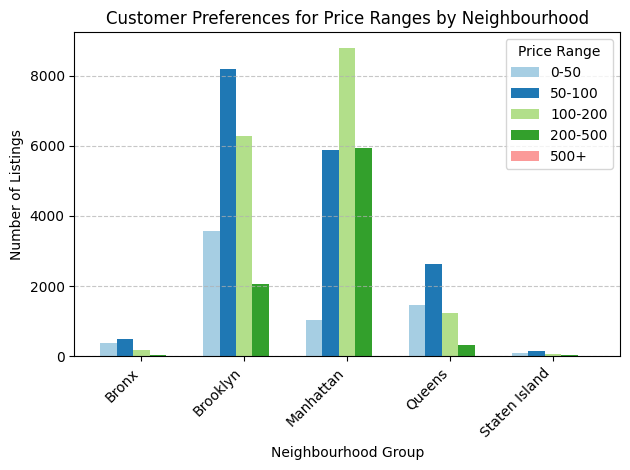

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# Understanding Customer Preferences

# TODO:
# 1. Create a new column 'price_range' by binning the 'price' into defined ranges with labels.
# 2. Group the data by 'neighbourhood_group' and 'price_range', then count listings and reshape using unstack().
# 3. Fill missing values with 0 for visualization consistency.
# 4. Generate a bar plot to show price range preferences across neighborhoods:
#    - Set figure size and use a distinct colormap.
#    - Rotate x-axis labels for clarity.
#    - Add title, axis labels, and legend.
#    - Display the plot.

import numpy as np
import matplotlib.pyplot as plt

# 1. Create a new column 'price_range' by binning the 'price' into defined ranges with labels
bins = [0, 50, 100, 200, 500, np.inf]
labels = ['0-50', '50-100', '100-200', '200-500', '500+']
df['price_range'] = pd.cut(df['price'], bins=bins, labels=labels, include_lowest=True)

# 2. Group the data by 'neighbourhood_group' and 'price_range', then count listings and reshape using unstack()
grouped_pr = df.groupby(['neighbourhood_group', 'price_range']).size().unstack(fill_value=0)

# 3. Fill missing values with 0 for visualization consistency (already handled via fill_value=0)
# grouped_pr = grouped_pr.fillna(0)

# 4. Generate a bar plot to show price range preferences across neighborhoods
plt.figure(figsize=(12, 6))
colors = plt.cm.Paired.colors
grouped_pr.plot(kind='bar', stacked=False, color=colors, width=0.8)

plt.title('Customer Preferences for Price Ranges by Neighbourhood')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Price Range')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


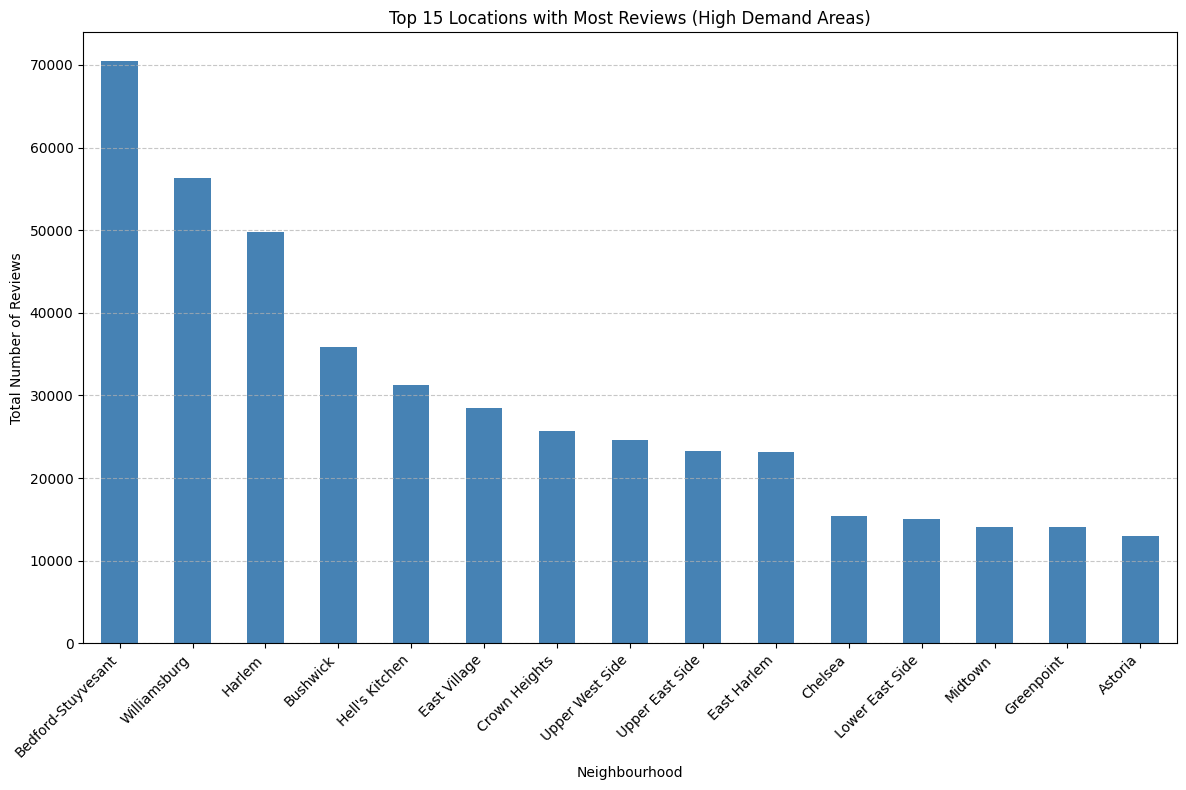

In [62]:

# TODO:
# 1. Group the data by 'neighbourhood' and sum the 'number_of_reviews' to find total reviews per area.
# 2. Sort the result in descending order to identify high-demand locations.
# 3. Create a bar plot for the top 15 neighborhoods with the most reviews:
#    - Set appropriate figure size and bar color.
#    - Rotate x-axis labels for readability.
#    - Add title, axis labels, and display the plot.
import matplotlib.pyplot as plt

# 1. Group the data by 'neighbourhood' and sum the 'number_of_reviews'
neigh_reviews = df.groupby('neighbourhood')['number_of_reviews'].sum()

# 2. Sort the result in descending order to identify high-demand locations
neigh_reviews_sorted = neigh_reviews.sort_values(ascending=False)

# 3. Select top 15 neighbourhoods
top15 = neigh_reviews_sorted.head(15)

# Create a bar plot for the top 15 neighbourhoods
plt.figure(figsize=(12, 8))
top15.plot(kind='bar', color='steelblue')

plt.title('Top 15 Locations with Most Reviews (High Demand Areas)')
plt.xlabel('Neighbourhood')
plt.ylabel('Total Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


## Pricing Startegy Analysis

/tmp/ipykernel_171/607834938.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_price_group, x='neighbourhood_group', y='price', palette='viridis')


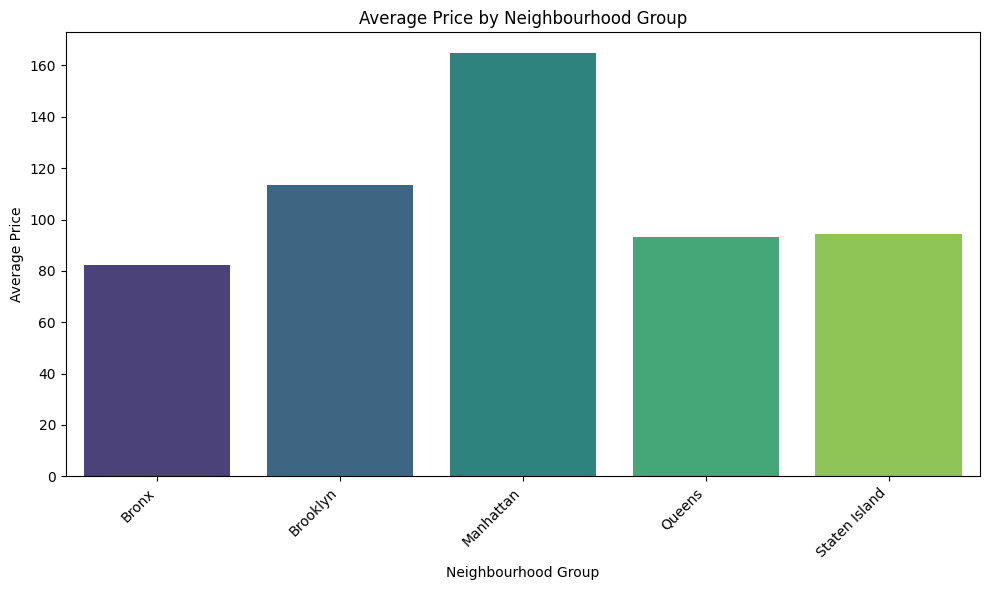

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pricing Strategy Analysis

# TODO:
# 1. Group the data by 'neighbourhood_group' and calculate the average price.
# 2. Reset the index to prepare for plotting.
# 3. Create a bar plot showing average price per neighborhood group:
#    - Use a distinct color for the bars.
#    - Add a title and axis labels.
#    - Display the plot.
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group the data by 'neighbourhood_group' and calculate the average price
avg_price_group = df.groupby('neighbourhood_group')['price'].mean().reset_index()

# 2. Reset the index (done via .reset_index above) so we have a DataFrame with columns: neighbourhood_group, price

# 3. Create a bar plot showing average price per neighbourhood group
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_price_group, x='neighbourhood_group', y='price', palette='viridis')

plt.title('Average Price by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Average Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


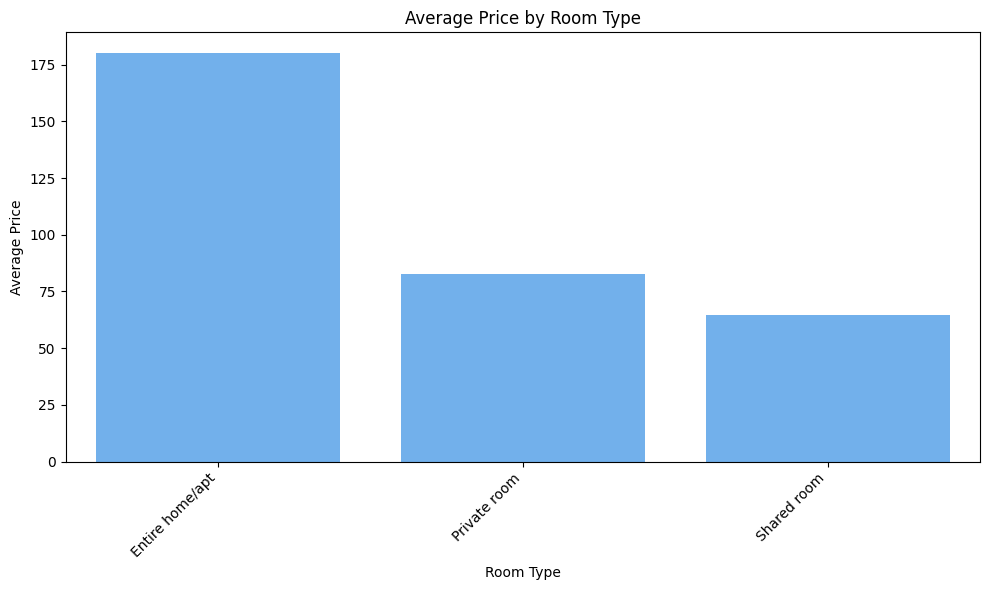

In [64]:
# TODO:
# 1. Group the data by 'room_type' and calculate the average price.
# 2. Reset the index to prepare the data for plotting.
# 3. Create a bar plot to show how average price varies by room type:
#    - Set figure size and choose a bar color.
#    - Add a title and axis labels.
#    - Display the plot.
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group the data by 'room_type' and calculate the average price.
avg_price_room = df.groupby('room_type')['price'].mean().reset_index()

# 2. Reset the index is done via .reset_index() above so we have columns: room_type, price

# 3. Create a bar plot to show how average price varies by room type:
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_price_room, x='room_type', y='price', color='#5EB1FF')

plt.title('Average Price by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Average Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


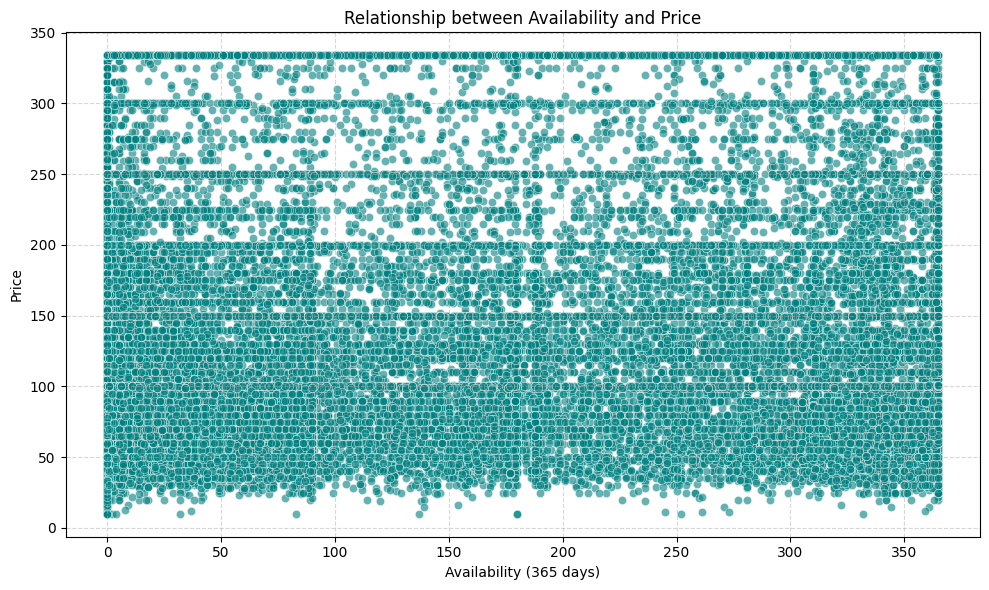

In [65]:
# TODO:
# 1. Create a scatter plot to visualize the relationship between 'availability_365' and 'price'.
#    - Set figure size, point transparency (alpha), and color.
#    - Use seaborn's scatterplot for better aesthetics.
# 2. Add title and axis labels to clearly describe the plot.
# 3. Display the plot.

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a scatter plot to visualize the relationship between 'availability_365' and 'price'
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='availability_365', y='price', alpha=0.6, color='teal')

# 2. Add title and axis labels
plt.title('Relationship between Availability and Price')
plt.xlabel('Availability (365 days)')
plt.ylabel('Price')
plt.grid(True, linestyle='--', alpha=0.5)

# 3. Display the plot
plt.tight_layout()
plt.show()


## Growth opportunity Analysis

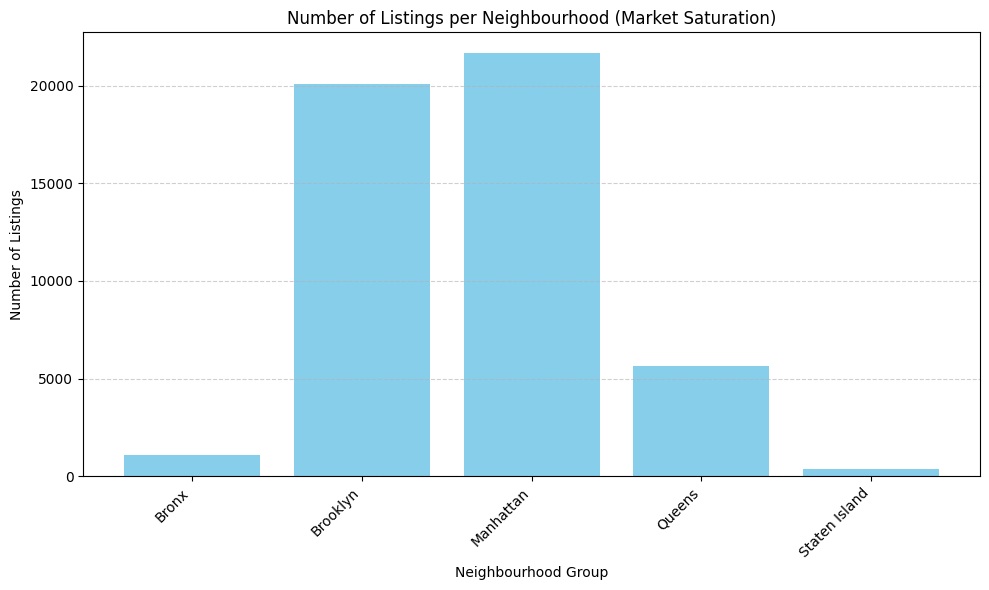

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Market Competition & Growth Opportunities

# TODO:
# 1. Count the number of listings per 'neighbourhood_group' to assess market saturation.
# 2. Reset the index and rename columns for clarity.
# 3. Create a bar plot to visualize the number of listings per neighborhood group:
#    - Set figure size and choose a distinct bar color.
#    - Rotate x-axis labels for better readability.
#    - Add title and axis labels.
#    - Display the plot.

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Count the number of listings per 'neighbourhood_group'
listing_counts = df.groupby('neighbourhood_group').size().reset_index(name='listing_count')

# 2. Reset index & rename columns done above via reset_index & name parameter

# 3. Create a bar plot
plt.figure(figsize=(10, 6))
plt.bar(listing_counts['neighbourhood_group'], listing_counts['listing_count'], color='skyblue')

plt.title('Number of Listings per Neighbourhood (Market Saturation)')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


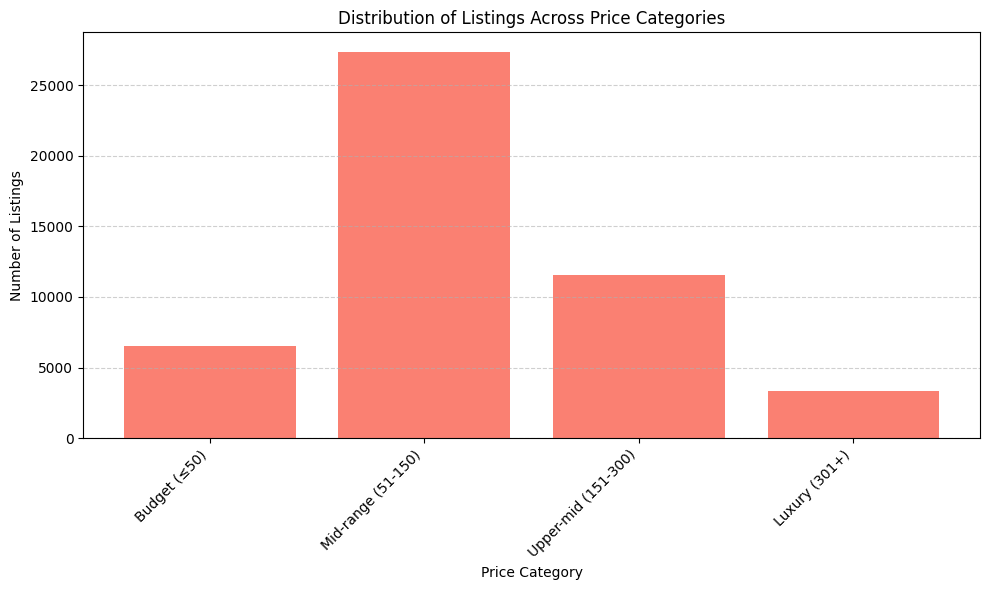

In [67]:
# TODO:
# 1. Create a new column 'price_category' by binning the 'price' into defined categories (e.g., Budget, Luxury).
# 2. Count the number of listings in each price category to understand market competition.
# 3. Rename the resulting columns for clarity.
# 4. Create a bar plot to visualize the distribution of listings across price categories:
#    - Set figure size and bar color.
#    - Rotate x-axis labels for readability.
#    - Add title and axis labels.
#    - Display the plot.
import matplotlib.pyplot as plt
import pandas as pd

# 1. Create a new column 'price_category' by binning the 'price' into defined categories
bins = [0, 50, 150, 300, float('inf')]
labels = ['Budget (≤50)', 'Mid-range (51-150)', 'Upper-mid (151-300)', 'Luxury (301+)']
df['price_category'] = pd.cut(df['price'], bins=bins, labels=labels, include_lowest=True)

# 2. Count the number of listings in each price category
price_cat_counts = df['price_category'].value_counts().sort_index().reset_index()
price_cat_counts.columns = ['price_category', 'listing_count']

# 3. Create a bar plot to visualize the distribution of listings across price categories
plt.figure(figsize=(10, 6))
plt.bar(price_cat_counts['price_category'], price_cat_counts['listing_count'], color='salmon')

plt.title('Distribution of Listings Across Price Categories')
plt.xlabel('Price Category')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


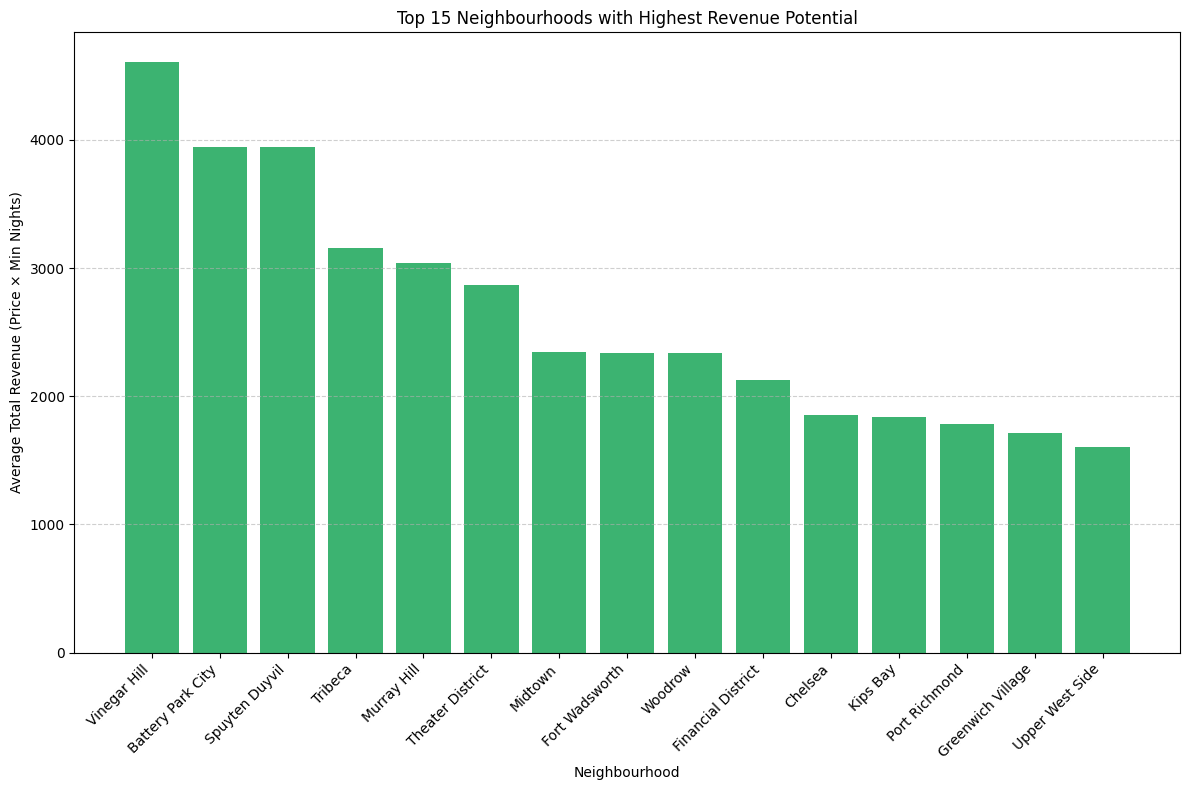

In [68]:
# TODO:
# 1. Create a new column 'total_revenue' by multiplying 'price' with 'minimum_nights'.
# 2. Group data by 'neighbourhood' and calculate average total revenue to estimate potential earnings.
# 3. Sort the neighborhoods by revenue potential in descending order.
# 4. Create a bar plot for the top 15 neighborhoods with the highest average revenue:
#    - Set figure size and bar color.
#    - Rotate x-axis labels for readability.
#    - Add title and axis labels.
#    - Display the plot.
import matplotlib.pyplot as plt

# 1. Create the new column 'total_revenue' = price × minimum_nights
df['total_revenue'] = df['price'] * df['minimum_nights']

# 2. Group data by 'neighbourhood' and calculate average total revenue
avg_rev_by_neigh = df.groupby('neighbourhood')['total_revenue'].mean().reset_index()

# 3. Sort the neighbourhoods by revenue potential (descending order)
top15_rev = avg_rev_by_neigh.sort_values(by='total_revenue', ascending=False).head(15)

# 4. Create a bar plot for the top 15 neighbourhoods
plt.figure(figsize=(12, 8))
plt.bar(top15_rev['neighbourhood'], top15_rev['total_revenue'], color='mediumseagreen')

plt.title('Top 15 Neighbourhoods with Highest Revenue Potential')
plt.xlabel('Neighbourhood')
plt.ylabel('Average Total Revenue (Price × Min Nights)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

